## Практика 09.
## Русскоязычный NER: BANK vs BROKER, Transformer vs LLM


Конфигурация: **только CPU**, компактная русскоязычная модель, сравнение `Transformer vs LLM`.

<img src="https://www.kinozoopark.ru/wp-content/uploads/2018/03/1380710300_3103-65c7b910.jpg" width="100" align="top">


### Сущности:

- `BANK` — банк как финансовая организация для переводов, счетов, кредитов, зачислений;
- `BROKER` — брокер, биржевая площадка, инвестиционная платформа или брокерский сервис;
- `AMOUNT` — сумма или количественный финансовый параметр;
- `TICKER` — тикер ценной бумаги, ETF, криптовалюты или другого инструмента.

Это позволяет обсуждать не только извлечение сущностей, но и **гранулярность схемы разметки**.


### Зависимости
```bash
pip install transformers datasets seqeval torch sentencepiece requests pandas --index-url https://download.pytorch.org/whl/cpu
```
```bash
А также: !pip install -U "accelerate>=1.1.0" "transformers[torch]"
```

Successfully installed accelerate-1.13.0 transformers-5.5.0 - это всего лишь прошла неделя!

In [1]:
import json
import time
import random
import warnings
from dataclasses import dataclass

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests
import torch
import seqeval.metrics as seqeval_metrics

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    pipeline,
)
from transformers.trainer_callback import TrainerCallback
from transformers.utils.notebook import NotebookProgressCallback

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cpu'
MODEL_NAME = 'cointegrated/rubert-tiny2'
MODEL_OUTPUT_DIR = './model'

print(f'Устройство: {DEVICE.upper()}')
print(f'Модель: {MODEL_NAME}')
print(f'Каталог сохранения: {MODEL_OUTPUT_DIR}')


Устройство: CPU
Модель: cointegrated/rubert-tiny2
Каталог сохранения: ./model


### Часть 1. Новая схема меток

Теперь используем 9 классов в BIO-представлении:
- `O`
- `B-AMOUNT`, `I-AMOUNT`
- `B-TICKER`, `I-TICKER`
- `B-BANK`, `I-BANK`
- `B-BROKER`, `I-BROKER`


In [2]:
label_list = [
    'O',
    'B-AMOUNT', 'I-AMOUNT',
    'B-TICKER', 'I-TICKER',
    'B-BANK', 'I-BANK',
    'B-BROKER', 'I-BROKER',
]

label2id = {lbl: i for i, lbl in enumerate(label_list)}
id2label = {i: lbl for lbl, i in label2id.items()}

print(label_list)


['O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'I-TICKER', 'B-BANK', 'I-BANK', 'B-BROKER', 'I-BROKER']


### Часть 2. Более содержательный датасет

Ниже используется расширенный учебный датасет, где банк и брокер размечаются раздельно.

Замечания:
- `Сбербанк`, `ВТБ`, `Альфа-Банк`, `Газпромбанк`, `Райффайзен` — это `BANK`;
- `БКС`, `Финам`, `Т-Инвестиции`, `Interactive Brokers`, `Binance`, `Bybit`, `Coinbase`, `Мосбиржа` — это `BROKER`;
- `ИИС` здесь трактуем как брокерский/инвестиционный контекст и относим к `BROKER`;
- `ETF FXRL`, `ETF FXUS`, `ETF TMOS` в этой версии считаем **инструментами/продуктами брокерского контура** и относим к `BROKER`, если они записаны как единый продукт.


In [3]:
raw_train = [
    {'tokens': ['Клиент', 'купил', '12', 'акций', 'SBER', 'по', '318', 'RUB', 'через', 'Сбербанк', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BANK', 'O']},
    {'tokens': ['Инвестор', 'продал', '5', 'акций', 'GAZP', 'по', '176', 'RUB', 'через', 'БКС', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BROKER', 'O']},
    {'tokens': ['На', 'счет', 'в', 'ВТБ', 'поступило', '145000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'O', 'B-BANK', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Перевод', '8500', 'RUB', 'выполнен', 'через', 'Т-Банк', '.'], 'ner_tags': ['O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'O', 'B-BANK', 'O']},
    {'tokens': ['Через', 'Binance', 'пользователь', 'купил', 'BTC', 'на', '2300', 'USD', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'O', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Через', 'Bybit', 'трейдер', 'купил', 'ETH', 'на', '1800', 'USD', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'O', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Портфель', 'пополнили', 'на', '2500', 'USD', 'через', 'Interactive', 'Brokers', '.'], 'ner_tags': ['O', 'O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BROKER', 'I-BROKER', 'O']},
    {'tokens': ['Брокер', 'открыл', 'позицию', 'в', 'AAPL', 'объемом', '3', 'акции', '.'], 'ner_tags': ['O', 'O', 'O', 'O', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Покупка', 'ETF', 'FXRL', 'на', '12000', 'RUB', 'прошла', 'через', 'Финам', '.'], 'ner_tags': ['O', 'B-BROKER', 'I-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'O', 'B-BROKER', 'O']},
    {'tokens': ['Клиент', 'отправил', '70000', 'RUB', 'в', 'Альфа-Банк', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BANK', 'O']},
    {'tokens': ['На', 'ИИС', 'зачислили', '40000', 'RUB', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Трейдер', 'докупил', '12', 'акций', 'LKOH', 'через', 'Т-Инвестиции', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-BROKER', 'O']},
    {'tokens': ['Покупка', 'облигаций', 'через', 'БКС', 'составила', '25000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Клиент', 'купил', '7', 'акций', 'ROSN', 'по', '612', 'RUB', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Инвестор', 'приобрел', '15', 'акций', 'YDEX', 'через', 'Т-Инвестиции', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-BROKER', 'O']},
    {'tokens': ['На', 'брокерский', 'счет', 'в', 'Финам', 'поступило', '50000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'O', 'O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Через', 'Мосбиржу', 'инвестор', 'купил', '20', 'акций', 'MTSS', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O']},
    {'tokens': ['Клиент', 'приобрел', 'ETF', 'SBMX', 'на', '9000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'B-BROKER', 'I-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Через', 'Открытие', 'Брокер', 'купили', '4', 'акции', 'NVTK', '.'], 'ner_tags': ['O', 'B-BROKER', 'I-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O']},
    {'tokens': ['На', 'кошелек', 'поступило', '0.15', 'BTC', 'с', 'Binance', '.'], 'ner_tags': ['O', 'O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BROKER', 'O']},
    {'tokens': ['Инвестор', 'купил', '2', 'лота', 'TATN', 'по', '720', 'RUB', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Перевод', '300000', 'RUB', 'отправлен', 'в', 'Газпромбанк', '.'], 'ner_tags': ['O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'O', 'B-BANK', 'O']},
    {'tokens': ['Через', 'Coinbase', 'пользователь', 'купил', 'SOL', 'на', '950', 'USD', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'O', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Клиент', 'пополнил', 'ИИС', 'на', '60000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Через', 'Атон', 'купили', '10', 'акций', 'PLZL', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O']},
    {'tokens': ['Покупка', 'ETF', 'TMOS', 'обошлась', 'в', '15000', 'RUB', '.'], 'ner_tags': ['O', 'B-BROKER', 'I-BROKER', 'O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Клиент', 'купил', '11', 'акций', 'CHMF', 'по', '1650', 'RUB', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Средства', 'в', 'размере', '98000', 'RUB', 'поступили', 'в', 'Райффайзен', '.'], 'ner_tags': ['O', 'O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'O', 'B-BANK', 'O']},
    {'tokens': ['Инвестор', 'купил', '6', 'акций', 'MAGN', 'через', 'БКС', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-BROKER', 'O']},
    {'tokens': ['На', 'карту', 'в', 'Сбербанк', 'зачислили', '120000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'O', 'B-BANK', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Через', 'Финам', 'инвестор', 'купил', '8', 'акций', 'GAZP', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O']},
    {'tokens': ['Клиент', 'погасил', 'кредит', 'в', 'ВТБ', 'на', '45000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'O', 'O', 'B-BANK', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Через', 'Мосбиржу', 'купили', 'ETF', 'FXUS', 'на', '13000', 'RUB', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'B-BROKER', 'I-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
]

raw_val = [
    {'tokens': ['Клиент', 'купил', '8', 'акций', 'ROSN', 'по', '610', 'RUB', 'через', 'Сбербанк', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BANK', 'O']},
    {'tokens': ['На', 'счет', 'в', 'Тинькофф', 'поступило', '90000', 'RUB', '.'], 'ner_tags': ['O', 'O', 'O', 'B-BANK', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Инвестор', 'купил', 'ETH', 'на', '1800', 'USD', 'через', 'Bybit', '.'], 'ner_tags': ['O', 'O', 'B-TICKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'B-BROKER', 'O']},
    {'tokens': ['Через', 'БКС', 'купили', '15', 'акций', 'YDEX', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O']},
    {'tokens': ['Покупка', 'ETF', 'FXUS', 'составила', '14000', 'RUB', '.'], 'ner_tags': ['O', 'B-BROKER', 'I-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['На', 'ИИС', 'зачислили', '25000', 'RUB', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O']},
    {'tokens': ['Клиент', 'купил', '3', 'акции', 'AAPL', 'через', 'Interactive', 'Brokers', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O', 'B-BROKER', 'I-BROKER', 'O']},
    {'tokens': ['Перевод', '125000', 'RUB', 'отправлен', 'в', 'Газпромбанк', '.'], 'ner_tags': ['O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'O', 'B-BANK', 'O']},
    {'tokens': ['Через', 'Финам', 'купили', '6', 'акций', 'LKOH', '.'], 'ner_tags': ['O', 'B-BROKER', 'O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'O']},
    {'tokens': ['Клиент', 'получил', '70000', 'RUB', 'на', 'карту', 'в', 'Альфа-Банк', '.'], 'ner_tags': ['O', 'O', 'B-AMOUNT', 'I-AMOUNT', 'O', 'O', 'O', 'B-BANK', 'O']},
]

for split in (raw_train, raw_val):
    for ex in split:
        ex['ner_tags'] = [label2id[tag] for tag in ex['ner_tags']]

dataset = DatasetDict({
    'train': Dataset.from_list(raw_train),
    'validation': Dataset.from_list(raw_val),
})

print(f'Размер train: {len(dataset["train"])}')
print(f'Размер validation: {len(dataset["validation"])}')


Размер train: 33
Размер validation: 10


### Часть 3. Токенизация и выравнивание BIO-меток


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True,
        max_length=72,
    )

    all_labels = []
    for i, ner_tags in enumerate(examples['ner_tags']):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_id = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(ner_tags[word_id])
            else:
                lbl = ner_tags[word_id]
                if lbl % 2 == 1:
                    lbl += 1
                label_ids.append(lbl)
            prev_word_id = word_id

        all_labels.append(label_ids)

    tokenized['labels'] = all_labels
    return tokenized

tokenized = dataset.map(tokenize_and_align_labels, batched=True)

sample = tokenized['train'][0]
sample_tokens = tokenizer.convert_ids_to_tokens(sample['input_ids'])
sample_labels = ['IGN' if x == -100 else id2label[x] for x in sample['labels']]

for tok, lbl in zip(sample_tokens, sample_labels):
    print(f'{tok:<18} {lbl}')


Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

[CLS]              IGN
Клиент             O
купил              O
12                 B-AMOUNT
акций              I-AMOUNT
SB                 B-TICKER
##ER               I-TICKER
по                 O
318                B-AMOUNT
RU                 I-AMOUNT
##B                I-AMOUNT
через              O
Сбербанк           B-BANK
.                  O
[SEP]              IGN


### Часть 4. Fine-tuning компактного русскоязычного трансформера на CPU


In [5]:
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    preds = np.argmax(logits, axis=-1)

    true_labels = [[label_list[l] for l in row if l != -100] for row in labels]
    true_preds = [
        [label_list[p] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(preds, labels)
    ]

    report = seqeval_metrics.classification_report(
        true_labels,
        true_preds,
        output_dict=True,
        zero_division=0,
    )

    micro = report.get('micro avg', {})
    return {
        'f1': micro.get('f1-score', 0.0),
        'precision': micro.get('precision', 0.0),
        'recall': micro.get('recall', 0.0),
    }

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

training_args = TrainingArguments(
    output_dir=MODEL_OUTPUT_DIR,
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    use_cpu=True,
    report_to='none',
    save_total_limit=1,
    seed=SEED,
)

data_collator = DataCollatorForTokenClassification(tokenizer)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Старт fine-tuning...")
t0 = time.time()
train_result = trainer.train()
train_time = time.time() - t0

print(f"Обучение заняло {train_time:.2f} секунд")



Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expec

Старт fine-tuning...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,1.662522,1.059490,0.285714,0.375000,0.230769
2,0.842873,0.538269,0.716981,0.703704,0.730769
3,0.483657,0.318866,0.830189,0.814815,0.846154
4,0.284424,0.204414,0.821429,0.766667,0.884615
5,0.208513,0.139703,0.872727,0.827586,0.923077
6,0.139698,0.116321,0.888889,0.857143,0.923077
7,0.125284,0.091116,0.943396,0.925926,0.961538
8,0.084362,0.075283,0.943396,0.925926,0.961538
9,0.076197,0.069169,0.943396,0.925926,0.961538
10,0.073278,0.067552,0.943396,0.925926,0.961538


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

Обучение заняло 13.81 секунд


### Часть 5. Inference трансформера


In [6]:
import os
subdirs = [d for d in os.listdir(MODEL_OUTPUT_DIR) if d.startswith('checkpoint-')]
subdirs = sorted(subdirs, key=lambda x: int(x.split('-')[-1]))
last_ckpt = os.path.join(MODEL_OUTPUT_DIR, subdirs[-1])
print("Используем чекпоинт:", last_ckpt)

ner_pipeline = pipeline(
    'ner',
    model=last_ckpt,
    tokenizer=last_ckpt,
    aggregation_strategy='simple',
    device=-1,
)

def entities_from_transformer(text: str) -> dict:
    """
    Прогоняет текст через ner_pipeline и возвращает словарь
    с ключами AMOUNT, TICKER, BANK, BROKER.
    """
    result = {"AMOUNT": [], "TICKER": [], "BANK": [], "BROKER": []}
    preds = ner_pipeline(text)

    for ent in preds:
        label = ent["entity_group"]  # у нас тут: AMOUNT, TICKER, BANK, BROKER
        span = ent["word"]
        if label in result:
            if span not in result[label]:
                result[label].append(span)

    return result

examples = [
    'Клиент перевел 85000 RUB в Сбербанк.',
    'Через БКС инвестор купил 15 акций YDEX.',
    'Через Binance пользователь купил BTC на 2100 USD.',
    'На счет в ВТБ поступило 120000 RUB.',
]

for s in examples:
    t0 = time.time()
    ents = ner_pipeline(s)
    dt = time.time() - t0
    print('=' * 80)
    print(s)
    print(f'inference = {dt:.4f} s')
    for e in ents:
        print(f"{e['entity_group']:<10} {e['word']:<25} score={e['score']:.3f}")


Используем чекпоинт: ./model\checkpoint-63


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

Клиент перевел 85000 RUB в Сбербанк.
inference = 0.0050 s
AMOUNT     85000 RUB                 score=0.977
BANK       Сбербанк                  score=0.784
Через БКС инвестор купил 15 акций YDEX.
inference = 0.0041 s
BROKER     БКС                       score=0.929
AMOUNT     15 акций                  score=0.969
TICKER     YDEX                      score=0.868
Через Binance пользователь купил BTC на 2100 USD.
inference = 0.0030 s
BROKER     Binance                   score=0.917
TICKER     BTC                       score=0.790
AMOUNT     2100 USD                  score=0.971
На счет в ВТБ поступило 120000 RUB.
inference = 0.0020 s
BANK       ВТБ                       score=0.835
AMOUNT     120000 RUB                score=0.978


### Часть 6. LLM‑подход к NER через Ollama (Qwen 2.5)

ollama run qwen2.5:3b - горшочек вари!

In [7]:
# 6. LLM-подход к NER через локальный Ollama (Qwen 2.5)

import requests
import json

OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "qwen2.5:3b"  # та модель, которую запустили командой `ollama run qwen2.5:3b`

def check_ollama_available():
    try:
        r = requests.get("http://localhost:11434/api/tags", timeout=5)
        r.raise_for_status()
        print("✅ Ollama доступен, модели:", [m["name"] for m in r.json().get("models", [])])
        return True
    except Exception as e:
        print("❌ Ollama недоступен:", e)
        print("Убедитесь, что запущена команда `ollama run qwen2.5:3b` в отдельном терминале.")
        return False

ollama_ok = check_ollama_available()

✅ Ollama доступен, модели: ['qwen2.5:3b']


In [8]:
def build_llm_prompt(text: str) -> str:
    return f"""
Ты — модель, которая выделяет именованные сущности из русских финансовых текстов.

Тебе дан текст. Нужно найти и выписать следующие сущности:
- AMOUNT: суммы денег и количества активов (например, '15000 RUB', '10 акций', '0.5 BTC')
- TICKER: тикеры акций, фондов, криптовалют (например, 'SBER', 'BTC', 'FXUS')
- BANK: банки (например, 'Сбербанк', 'ВТБ')
- BROKER: брокеры и инвестиционные платформы (например, 'Тинькофф Инвестиции', 'БКС', 'Binance')

Очень важные правила:
1. Возвращай только JSON, без пояснений, текста и комментариев.
2. В JSON должны быть ключи ровно: "AMOUNT", "TICKER", "BANK", "BROKER".
3. Значения — это списки строк.
4. Строки должны быть точными подстроками исходного текста, без перефразирования.
5. Не выдумывай сущности, которых нет в тексте.

Формат ответа строго такой:
{{
  "AMOUNT": [],
  "TICKER": [],
  "BANK": [],
  "BROKER": []
}}

Текст:
{text}
""".strip()


def extract_entities_llm(text: str) -> dict:
    """
    Вызывает локальную LLM через Ollama и возвращает словарь с сущностями.
    Если что-то пошло не так, возвращает пустые списки по ключам.
    """
    if not ollama_ok:
        return {"AMOUNT": [], "TICKER": [], "BANK": [], "BROKER": []}

    prompt = build_llm_prompt(text)

    try:
        resp = requests.post(
            OLLAMA_URL,
            json={
                "model": OLLAMA_MODEL,
                "prompt": prompt,
                "stream": False,
            },
            timeout=120,
        )
        resp.raise_for_status()
        raw = resp.json()["response"].strip()
        # Попробуем вытащить JSON (иногда модель может добавить текст вокруг)
        # Берем подстроку между первой и последней фигурной скобкой
        start = raw.find("{")
        end = raw.rfind("}")
        if start != -1 and end != -1 and end > start:
            raw_json = raw[start:end+1]
        else:
            raw_json = raw

        data = json.loads(raw_json)
    except Exception as e:
        print("Ошибка при запросе к LLM или парсинге JSON:", e)
        print("Сырой ответ модели:\n", raw if 'raw' in locals() else "<нет ответа>")
        data = {}

    # Нормализуем результат
    result = {
        "AMOUNT": [],
        "TICKER": [],
        "BANK": [],
        "BROKER": [],
    }
    for key in result.keys():
        val = data.get(key, [])
        if isinstance(val, list):
            result[key] = [str(x) for x in val]
        elif isinstance(val, str) and val.strip():
            result[key] = [val.strip()]

    return result

In [9]:
# Тест LLM на тех же примерах, что и трансформерный NER

test_sentences = [
    "Клиент перевел 85000 RUB в Сбербанк.",
    "Через БКС инвестор купил 15 акций YDEX.",
    "Через Binance пользователь купил BTC на 2100 USD.",
    "На счет в ВТБ поступило 120000 RUB.",
]

if ollama_ok:
    for s in test_sentences:
        print("=" * 80)
        print("TEXT:", s)
        entities_llm = extract_entities_llm(s)
        print("LLM entities:", entities_llm)
else:
    print("LLM не запущена, эту часть можно пропустить или вернуться к ней позже.")

TEXT: Клиент перевел 85000 RUB в Сбербанк.
LLM entities: {'AMOUNT': ['85000 RUB'], 'TICKER': [], 'BANK': ['Сбербанк'], 'BROKER': []}
TEXT: Через БКС инвестор купил 15 акций YDEX.
LLM entities: {'AMOUNT': [], 'TICKER': [], 'BANK': ['БКС'], 'BROKER': ['БКС']}
TEXT: Через Binance пользователь купил BTC на 2100 USD.
LLM entities: {'AMOUNT': ['2100 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance']}
TEXT: На счет в ВТБ поступило 120000 RUB.
LLM entities: {'AMOUNT': ['120000 RUB'], 'TICKER': [], 'BANK': ['ВТБ'], 'BROKER': []}


### Часть 7. Соревнование Transformer vs LLM

Теперь сравнение становится интереснее, потому что одна и та же модель должна различать `BANK` и `BROKER`.


In [10]:
@dataclass
class LabeledExample:
    text: str
    entities: dict

test_examples = [
    LabeledExample(
        text='Клиент купил 12 акций SBER по 318 RUB через Сбербанк.',
        entities={'AMOUNT': ['12 акций', '318 RUB'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': []},
    ),
    LabeledExample(
        text='Через Binance инвестор купил BTC на 2400 USD.',
        entities={'AMOUNT': ['2400 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance']},
    ),
    LabeledExample(
        text='На счет в ВТБ поступило 125000 RUB.',
        entities={'AMOUNT': ['125000 RUB'], 'TICKER': [], 'BANK': ['ВТБ'], 'BROKER': []},
    ),
    LabeledExample(
        text='Брокер купил 3 акции AAPL через Interactive Brokers.',
        entities={'AMOUNT': ['3 акции'], 'TICKER': ['AAPL'], 'BANK': [], 'BROKER': ['Interactive Brokers']},
    ),
    LabeledExample(
        text='Инвестор направил 15000 RUB на ИИС.',
        entities={'AMOUNT': ['15000 RUB'], 'TICKER': [], 'BANK': [], 'BROKER': ['ИИС']},
    ),
    LabeledExample(
        text='Через БКС купили 15 акций YDEX.',
        entities={'AMOUNT': ['15 акций'], 'TICKER': ['YDEX'], 'BANK': [], 'BROKER': ['БКС']},
    ),
    LabeledExample(
        text='Клиент получил 70000 RUB на карту в Альфа-Банк.',
        entities={'AMOUNT': ['70000 RUB'], 'TICKER': [], 'BANK': ['Альфа-Банк'], 'BROKER': []},
    ),
    LabeledExample(
        text='Через Мосбиржу купили ETF FXUS на 13000 RUB.',
        entities={'AMOUNT': ['13000 RUB'], 'TICKER': [], 'BANK': [], 'BROKER': ['Мосбиржа', 'ETF FXUS']},
    ),
]

def normalize_span(x: str) -> str:
    return " ".join(str(x).strip().lower().split())

def prf1(gold, pred):
    gold_set = set(map(normalize_span, gold))
    pred_set = set(map(normalize_span, pred))
    tp = len(gold_set & pred_set)
    fp = len(pred_set - gold_set)
    fn = len(gold_set - pred_set)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'precision': precision, 'recall': recall, 'f1': f1}

agg = {
    'Transformer': {'AMOUNT': [], 'TICKER': [], 'BANK': [], 'BROKER': [], 'time': []},
    'LLM': {'AMOUNT': [], 'TICKER': [], 'BANK': [], 'BROKER': [], 'time': []},
}

rows = []

for ex in test_examples:
    print('=' * 100)
    print('Текст:', ex.text)
    print('Эталон:', ex.entities)

    t0 = time.time()
    pred_tr = entities_from_transformer(ex.text)
    dt_tr = time.time() - t0
    agg['Transformer']['time'].append(dt_tr)

    t1 = time.time()
    pred_llm = extract_entities_llm(ex.text)
    dt_llm = time.time() - t1
    agg['LLM']['time'].append(dt_llm)

    print('\n[Transformer]', f'(t = {dt_tr:.4f} s)')
    print(pred_tr)
    print('\n[LLM]', f'(t = {dt_llm:.4f} s)')
    print(pred_llm)

    for model_name, pred, dt in [('Transformer', pred_tr, dt_tr), ('LLM', pred_llm, dt_llm)]:
        for ent_type in ['AMOUNT', 'TICKER', 'BANK', 'BROKER']:
            m = prf1(ex.entities[ent_type], pred[ent_type])
            agg[model_name][ent_type].append(m)
            rows.append({
                'text': ex.text,
                'model': model_name,
                'entity_type': ent_type,
                'precision': round(m['precision'], 4),
                'recall': round(m['recall'], 4),
                'f1': round(m['f1'], 4),
                'time_sec': round(dt, 4),
            })
            print(f"  {model_name:11s} {ent_type:8s}: P={m['precision']:.2f} R={m['recall']:.2f} F1={m['f1']:.2f}")

details_df = pd.DataFrame(rows)
print('\n' + '=' * 100)
print('ПОДРОБНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
display(details_df)

summary_rows = []
for model_name in ['Transformer', 'LLM']:
    for ent_type in ['AMOUNT', 'TICKER', 'BANK', 'BROKER']:
        vals = agg[model_name][ent_type]
        summary_rows.append({
            'model': model_name,
            'entity_type': ent_type,
            'precision': round(sum(x['precision'] for x in vals) / len(vals), 4),
            'recall': round(sum(x['recall'] for x in vals) / len(vals), 4),
            'f1': round(sum(x['f1'] for x in vals) / len(vals), 4),
            'avg_time_sec': round(sum(agg[model_name]['time']) / len(agg[model_name]['time']), 4),
        })

summary_df = pd.DataFrame(summary_rows)
print('\nСРЕДНИЕ МЕТРИКИ ПО ТИПАМ СУЩНОСТЕЙ')
display(summary_df)


Текст: Клиент купил 12 акций SBER по 318 RUB через Сбербанк.
Эталон: {'AMOUNT': ['12 акций', '318 RUB'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': []}

[Transformer] (t = 0.0050 s)
{'AMOUNT': ['12 акций', '318 RUB'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': []}

[LLM] (t = 3.6077 s)
{'AMOUNT': ['12 акций'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': []}
  Transformer AMOUNT  : P=1.00 R=1.00 F1=1.00
  Transformer TICKER  : P=1.00 R=1.00 F1=1.00
  Transformer BANK    : P=1.00 R=1.00 F1=1.00
  Transformer BROKER  : P=0.00 R=0.00 F1=0.00
  LLM         AMOUNT  : P=1.00 R=0.50 F1=0.67
  LLM         TICKER  : P=1.00 R=1.00 F1=1.00
  LLM         BANK    : P=1.00 R=1.00 F1=1.00
  LLM         BROKER  : P=0.00 R=0.00 F1=0.00
Текст: Через Binance инвестор купил BTC на 2400 USD.
Эталон: {'AMOUNT': ['2400 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance']}

[Transformer] (t = 0.0046 s)
{'AMOUNT': ['2400 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance'

,text,model,entity_type,precision,recall,f1,time_sec
0,Клиент купил 12 акций SBER по 318 RUB через Сб...,Transformer,AMOUNT,1.0,1.0,1.0000,0.0050
1,Клиент купил 12 акций SBER по 318 RUB через Сб...,Transformer,TICKER,1.0,1.0,1.0000,0.0050
2,Клиент купил 12 акций SBER по 318 RUB через Сб...,Transformer,BANK,1.0,1.0,1.0000,0.0050
3,Клиент купил 12 акций SBER по 318 RUB через Сб...,Transformer,BROKER,0.0,0.0,0.0000,0.0050
4,Клиент купил 12 акций SBER по 318 RUB через Сб...,LLM,AMOUNT,1.0,0.5,0.6667,3.6077
...,...,...,...,...,...,...,...
59,Через Мосбиржу купили ETF FXUS на 13000 RUB.,Transformer,BROKER,0.5,0.5,0.5000,0.0046
60,Через Мосбиржу купили ETF FXUS на 13000 RUB.,LLM,AMOUNT,1.0,1.0,1.0000,3.7229
61,Через Мосбиржу купили ETF FXUS на 13000 RUB.,LLM,TICKER,0.0,0.0,0.0000,3.7229
62,Через Мосбиржу купили ETF FXUS на 13000 RUB.,LLM,BANK,0.0,0.0,0.0000,3.7229



СРЕДНИЕ МЕТРИКИ ПО ТИПАМ СУЩНОСТЕЙ


,model,entity_type,precision,recall,f1,avg_time_sec
0,Transformer,AMOUNT,1.0000,1.0000,1.0000,0.0042
1,Transformer,TICKER,0.5000,0.5000,0.5000,0.0042
2,Transformer,BANK,0.2500,0.2500,0.2500,0.0042
3,Transformer,BROKER,0.5625,0.5625,0.5625,0.0042
4,LLM,AMOUNT,0.8750,0.8125,0.8333,3.5562
5,LLM,TICKER,0.3750,0.3750,0.3750,3.5562
6,LLM,BANK,0.3750,0.3750,0.3750,3.5562
7,LLM,BROKER,0.3750,0.3750,0.3750,3.5562


### Выводы

Скорость. Трансформер стабильно дает ~0.008–0.012 s на предложение, LLM — ~9–11 s, то есть медленнее примерно в 1000 раз на CPU.

AMOUNT. Оба подхода сильные, но трансформер чаще бывает уверен (F1 = 1.0), LLM слегка уступает (F1 ≈ 0.83) из‑за пропусков вроде 318 RUB.

TICKER. Обе модели иногда промахиваются (FXUS, YDEX), но трансформер в среднем точнее (F1 0.5 против 0.375): он “честно” ограничен тем, что видел на fine-tuning.

BANK/BROKER. Здесь проявляется разница подходов:

- трансформер четко держит схему (но дробление типа “Альфа‑Банк” на Банк/Альфа - показывает, что токенизация и BIO все еще важны),

- LLM иногда путает роли (БКС → BANK+BROKER, отсутствие ИИС как брокера, отсутствие Мосбиржа), но при этом идеально вытаскивает “Альфа-Банк” как одну сущность.

## Практическая работа

1. **Класс EXCHANGE для бирж**

   - Добавьте новый тип сущностей `EXCHANGE` (биржи, например `Мосбиржа`, `СПБ Биржа`).
   - Расширьте список меток в коде (BIO-метки: `B-EXCHANGE`, `I-EXCHANGE`).
   - Обновите мини‑датасет: перенесите `Мосбиржа` из `BROKER` в `EXCHANGE`.
   - Переобучите модель и повторите сравнение с LLM (часть 7). Сравните F1 по `EXCHANGE`.

2. **Класс ACCOUNT_TYPE для типов счетов**

   - Добавьте новый тип `ACCOUNT_TYPE` (например, `ИИС`, “брокерский счет”, “карта”).
   - Расширьте список меток и переразметьте соответствующие предложения (вынесите `ИИС` из `BROKER` в `ACCOUNT_TYPE`).
   - Переобучите модель и посмотрите, как изменилась точность по `BROKER` и новому `ACCOUNT_TYPE`.

3. **ETF‑продукты vs брокеры**

   - Введите отдельный класс для продуктов, например `ETF_PRODUCT` или `FIN_PRODUCT`.
   - Отнесите сущности вида `ETF FXUS` к новому классу, а `БКС`, `Interactive Brokers`, `Тинькофф` оставьте в `BROKER`.
   - Обновите эталоны в части 7 и переоцените обе модели:
     - как изменился F1 по `BROKER`?
     - какова точность по новому классу продуктов?

4. **Confusion‑анализ BANK/BROKER**

   - Выберите предложения, где встречаются банки и/или брокеры.
   - Для трансформера и LLM соберите таблицу вида:

     - `gold = BANK, pred = BANK`
     - `gold = BANK, pred = BROKER`
     - `gold = BROKER, pred = BANK`
     - `gold = BANK/BROKER, pred = NONE`

   - Представьте результат либо в виде confusion‑матрицы, либо в виде таблицы с количеством ошибок каждого типа.
   - Сделайте краткий вывод: кто чаще путает банк и брокера — трансформер или LLM.

5. **Сравнение 2–3 моделей в CPU‑режиме**

   - Выберите 2–3 компактные русскоязычные или мультиязычные модели для NER/TokenClassification (например, небольшие варианты ruBERT или мультиязычных BERT/DistilBERT).
   - Для каждой модели:
     - замените `MODEL_NAME` в ноутбуке;
     - обучите на том же учебном датасете;
     - измерьте F1 по типам сущностей (AMOUNT, TICKER, BANK, BROKER, и новые классы, если вы их добавили);
     - измерьте среднее время inference на CPU на том же наборе примеров (как в части 7).
   - Сравните модели по качеству и скорости. Сделайте вывод: есть ли модель, которая даёт лучший компромисс “качество / время ответа” на CPU.

6. **Экспорт таблиц с результатами**

   - В конце части 7 у нас есть две таблицы: подробная (`df_results`) и агрегированная (`df_agg`).
   - Добавьте код сохранения в CSV:

     ```python
     df_results.to_csv("ner_llm_comparison_detailed.csv", index=False, encoding="utf-8")
     df_agg.to_csv("ner_llm_comparison_summary.csv", index=False, encoding="utf-8")
     print("CSV сохранены: ner_llm_comparison_detailed.csv и ner_llm_comparison_summary.csv")
     ```

   - Откройте CSV в табличном редакторе и проверьте:
     - где именно LLM выигрывает/проигрывает трансформеру;
     - по каким типам сущностей качество особенно отличается.


## 1. Расширенная схема меток

In [11]:
new_label_list = [
    'O',
    'B-AMOUNT', 'I-AMOUNT',
    'B-TICKER', 'I-TICKER',
    'B-BANK', 'I-BANK',
    'B-BROKER', 'I-BROKER',
    'B-EXCHANGE', 'I-EXCHANGE',
    'B-ACCOUNT_TYPE', 'I-ACCOUNT_TYPE',
    'B-FIN_PRODUCT', 'I-FIN_PRODUCT',
]

new_label2id = {lbl: i for i, lbl in enumerate(new_label_list)}
new_id2label = {i: lbl for lbl, i in new_label2id.items()}

print("Новые метки:", new_label_list)
print("Всего классов:", len(new_label_list))

Новые метки: ['O', 'B-AMOUNT', 'I-AMOUNT', 'B-TICKER', 'I-TICKER', 'B-BANK', 'I-BANK', 'B-BROKER', 'I-BROKER', 'B-EXCHANGE', 'I-EXCHANGE', 'B-ACCOUNT_TYPE', 'I-ACCOUNT_TYPE', 'B-FIN_PRODUCT', 'I-FIN_PRODUCT']
Всего классов: 15


## 2. Переразметка датасета с учётом новых классов

In [12]:
def update_ner_tags(example, is_train=True):
    tokens = example['tokens']
    old_tags = example['ner_tags']
    old_label_str = [label_list[tag] if tag != -100 else 'O' for tag in old_tags]
    
    new_tags = []
    for token, old_str in zip(tokens, old_label_str):
        new_str = old_str
        
        if token in ('Мосбиржа', 'Мосбиржу', 'СПБ', 'СПБ Биржа'):
            if old_str.startswith('B-'):
                new_str = 'B-EXCHANGE'
            elif old_str.startswith('I-'):
                new_str = 'I-EXCHANGE'
            else:
                new_str = 'B-EXCHANGE'
        elif token in ('ИИС', 'брокерский', 'счет', 'карту', 'карта'):
            if old_str.startswith('B-'):
                new_str = 'B-ACCOUNT_TYPE'
            elif old_str.startswith('I-'):
                new_str = 'I-ACCOUNT_TYPE'
            else:
                new_str = 'B-ACCOUNT_TYPE'
        elif token in ('ETF', 'FXUS', 'TMOS', 'FXRL', 'SBMX'):
            if old_str.startswith('B-') or old_str.startswith('I-'):
                new_str = 'B-FIN_PRODUCT' if old_str.startswith('B-') else 'I-FIN_PRODUCT'
            else:
                new_str = 'B-FIN_PRODUCT'
        elif token == 'ETF' and (len(tokens) > i+1 and tokens[i+1] in ('FXUS','TMOS','FXRL','SBMX')):
            new_str = 'B-FIN_PRODUCT'
        
        new_tags.append(new_label2id.get(new_str, new_label2id['O']))
    return {'tokens': tokens, 'ner_tags': new_tags}

new_raw_train = [update_ner_tags(ex, is_train=True) for ex in raw_train]
new_raw_val   = [update_ner_tags(ex, is_train=False) for ex in raw_val]

from datasets import Dataset, DatasetDict
new_dataset = DatasetDict({
    'train': Dataset.from_list(new_raw_train),
    'validation': Dataset.from_list(new_raw_val),
})

print("Размер train после переразметки:", len(new_dataset['train']))
print("Размер validation:", len(new_dataset['validation']))

sample_idx = 0
print("\nПример первого предложения в новой разметке:")
for tok, tag_id in zip(new_dataset['train'][sample_idx]['tokens'], new_dataset['train'][sample_idx]['ner_tags']):
    print(f"{tok:15} -> {new_id2label[tag_id]}")

Размер train после переразметки: 33
Размер validation: 10

Пример первого предложения в новой разметке:
Клиент          -> O
купил           -> O
12              -> B-AMOUNT
акций           -> I-AMOUNT
SBER            -> B-TICKER
по              -> O
318             -> B-AMOUNT
RUB             -> I-AMOUNT
через           -> O
Сбербанк        -> B-BANK
.               -> O


## 3. Токенизация и выравнивание меток для новой схемы

In [13]:
from transformers import AutoTokenizer

tokenizer_new = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels_new(examples):
    tokenized = tokenizer_new(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True,
        max_length=72,
    )
    all_labels = []
    for i, ner_tags in enumerate(examples['ner_tags']):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(ner_tags[word_id])
            else:
                lbl = ner_tags[word_id]
                if lbl not in (-100, new_label2id['O']):
                    if lbl % 2 == 1:
                        lbl += 1
                label_ids.append(lbl)
            prev_word_id = word_id
        all_labels.append(label_ids)
    tokenized['labels'] = all_labels
    return tokenized

new_tokenized = new_dataset.map(tokenize_and_align_labels_new, batched=True)

print("Токенизация завершена.")

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Токенизация завершена.


## 4. Дообучение модели на расширенной схеме

In [14]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
import numpy as np
import seqeval.metrics as seqeval_metrics
import time

model_new = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(new_label_list),
    id2label=new_id2label,
    label2id=new_label2id,
    ignore_mismatched_sizes=True,
)

training_args_new = TrainingArguments(
    output_dir='./model_new_scheme',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    use_cpu=True,
    report_to='none',
    save_total_limit=1,
    seed=SEED,
)

def compute_metrics_new(eval_preds):
    logits, labels = eval_preds
    preds = np.argmax(logits, axis=-1)
    true_labels = [[new_label_list[l] for l in row if l != -100] for row in labels]
    true_preds = [[new_label_list[p] for p,l in zip(pred_row, label_row) if l != -100]
                  for pred_row, label_row in zip(preds, labels)]
    report = seqeval_metrics.classification_report(true_labels, true_preds, output_dict=True, zero_division=0)
    micro = report.get('micro avg', {})
    return {'f1': micro.get('f1-score', 0.0), 'precision': micro.get('precision', 0.0), 'recall': micro.get('recall', 0.0)}

data_collator_new = DataCollatorForTokenClassification(tokenizer_new)

trainer_new = Trainer(
    model=model_new,
    args=training_args_new,
    train_dataset=new_tokenized["train"],
    eval_dataset=new_tokenized["validation"],
    data_collator=data_collator_new,
    compute_metrics=compute_metrics_new,
)

print("Старт обучения на расширенной схеме...")
t0 = time.time()
trainer_new.train()
train_time_new = time.time() - t0
print(f"Обучение заняло {train_time_new:.2f} секунд")

trainer_new.save_model('./model_new_scheme_best')
tokenizer_new.save_pretrained('./model_new_scheme_best')
print("Модель сохранена в ./model_new_scheme_best")

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expec

Старт обучения на расширенной схеме...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,2.077708,1.491659,0.125000,0.150000,0.107143
2,1.323630,0.951744,0.406780,0.387097,0.428571
3,0.876619,0.631937,0.610169,0.580645,0.642857
4,0.624049,0.446485,0.771930,0.758621,0.785714
5,0.426173,0.318133,0.877193,0.862069,0.892857
6,0.339897,0.259040,0.892857,0.892857,0.892857
7,0.258548,0.198644,0.892857,0.892857,0.892857
8,0.197821,0.170011,0.928571,0.928571,0.928571
9,0.172589,0.159156,0.928571,0.928571,0.928571
10,0.162640,0.155047,0.928571,0.928571,0.928571


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

Обучение заняло 14.00 секунд


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена в ./model_new_scheme_best


## 5. Сравнение трансформера (новая схема) с LLM

In [15]:
import json
import requests
import time
from transformers import pipeline

ner_pipeline_new = pipeline(
    'ner',
    model='./model_new_scheme_best',
    tokenizer='./model_new_scheme_best',
    aggregation_strategy='simple',
    device=-1,
)

def entities_from_transformer_new(text: str) -> dict:
    result = {"AMOUNT": [], "TICKER": [], "BANK": [], "BROKER": [], 
              "EXCHANGE": [], "ACCOUNT_TYPE": [], "FIN_PRODUCT": []}
    preds = ner_pipeline_new(text)
    for ent in preds:
        label = ent["entity_group"]
        span = ent["word"]
        if label in result:
            if span not in result[label]:
                result[label].append(span)
    return result

test_examples_new = [
    {'text': 'Клиент купил 12 акций SBER по 318 RUB через Сбербанк.',
     'entities': {'AMOUNT': ['12 акций', '318 RUB'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': [], 'EXCHANGE': [], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': []}},
    {'text': 'Через Binance инвестор купил BTC на 2400 USD.',
     'entities': {'AMOUNT': ['2400 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance'], 'EXCHANGE': [], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': []}},
    {'text': 'На счет в ВТБ поступило 125000 RUB.',
     'entities': {'AMOUNT': ['125000 RUB'], 'TICKER': [], 'BANK': ['ВТБ'], 'BROKER': [], 'EXCHANGE': [], 'ACCOUNT_TYPE': ['счет'], 'FIN_PRODUCT': []}},
    {'text': 'Брокер купил 3 акции AAPL через Interactive Brokers.',
     'entities': {'AMOUNT': ['3 акции'], 'TICKER': ['AAPL'], 'BANK': [], 'BROKER': ['Interactive Brokers'], 'EXCHANGE': [], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': []}},
    {'text': 'Инвестор направил 15000 RUB на ИИС.',
     'entities': {'AMOUNT': ['15000 RUB'], 'TICKER': [], 'BANK': [], 'BROKER': [], 'EXCHANGE': [], 'ACCOUNT_TYPE': ['ИИС'], 'FIN_PRODUCT': []}},
    {'text': 'Через БКС купили 15 акций YDEX.',
     'entities': {'AMOUNT': ['15 акций'], 'TICKER': ['YDEX'], 'BANK': [], 'BROKER': ['БКС'], 'EXCHANGE': [], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': []}},
    {'text': 'Клиент получил 70000 RUB на карту в Альфа-Банк.',
     'entities': {'AMOUNT': ['70000 RUB'], 'TICKER': [], 'BANK': ['Альфа-Банк'], 'BROKER': [], 'EXCHANGE': [], 'ACCOUNT_TYPE': ['карту'], 'FIN_PRODUCT': []}},
    {'text': 'Через Мосбиржу купили ETF FXUS на 13000 RUB.',
     'entities': {'AMOUNT': ['13000 RUB'], 'TICKER': [], 'BANK': [], 'BROKER': [], 'EXCHANGE': ['Мосбиржу'], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': ['ETF FXUS']}},
]

def prf1(gold, pred):
    gold_set = set(" ".join(str(x).strip().lower().split()) for x in gold)
    pred_set = set(" ".join(str(x).strip().lower().split()) for x in pred)
    tp = len(gold_set & pred_set)
    fp = len(pred_set - gold_set)
    fn = len(gold_set - pred_set)
    prec = tp / (tp+fp) if tp+fp else 0.0
    rec = tp / (tp+fn) if tp+fn else 0.0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    return prec, rec, f1

all_results = []
for ex in test_examples_new:
    text = ex['text']
    gold = ex['entities']
    
    t0 = time.time()
    pred_tr = entities_from_transformer_new(text)
    time_tr = time.time() - t0
    
    t1 = time.time()
    pred_llm = extract_entities_llm(text)
    time_llm = time.time() - t1
    
    for model_name, pred, dt in [('Transformer_new', pred_tr, time_tr), ('LLM', pred_llm, time_llm)]:
        for ent_type in ['AMOUNT', 'TICKER', 'BANK', 'BROKER', 'EXCHANGE', 'ACCOUNT_TYPE', 'FIN_PRODUCT']:
            if ent_type not in pred:
                continue
            prec, rec, f1 = prf1(gold.get(ent_type, []), pred.get(ent_type, []))
            all_results.append({
                'text': text,
                'model': model_name,
                'entity_type': ent_type,
                'precision': prec,
                'recall': rec,
                'f1': f1,
                'time_sec': dt
            })
    print(f"\nТекст: {text}")
    print(f"Transformer_new: {pred_tr}")
    print(f"LLM: {pred_llm}")

import pandas as pd
df_results = pd.DataFrame(all_results)
df_agg = df_results.groupby(['model', 'entity_type'])[['precision','recall','f1','time_sec']].mean().reset_index()
print("\n=== Средние метрики по типам сущностей ===")
print(df_agg.round(4))

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]


Текст: Клиент купил 12 акций SBER по 318 RUB через Сбербанк.
Transformer_new: {'AMOUNT': ['12 акций', '318 RUB'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': [], 'EXCHANGE': [], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': []}
LLM: {'AMOUNT': ['318 RUB'], 'TICKER': ['SBER'], 'BANK': ['Сбербанк'], 'BROKER': []}

Текст: Через Binance инвестор купил BTC на 2400 USD.
Transformer_new: {'AMOUNT': ['2400 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance'], 'EXCHANGE': [], 'ACCOUNT_TYPE': [], 'FIN_PRODUCT': []}
LLM: {'AMOUNT': ['2400 USD'], 'TICKER': ['BTC'], 'BANK': [], 'BROKER': ['Binance']}

Текст: На счет в ВТБ поступило 125000 RUB.
Transformer_new: {'AMOUNT': ['125000 RUB'], 'TICKER': [], 'BANK': ['ВТБ'], 'BROKER': [], 'EXCHANGE': [], 'ACCOUNT_TYPE': ['счет'], 'FIN_PRODUCT': []}
LLM: {'AMOUNT': ['125000 RUB'], 'TICKER': [], 'BANK': ['ВТБ'], 'BROKER': []}

Текст: Брокер купил 3 акции AAPL через Interactive Brokers.
Transformer_new: {'AMOUNT': ['3 акции'], 'TICKER': ['AAPL'], 'BANK':

## 6. Confusion-анлаиз

Confusion для Transformer (новая схема):


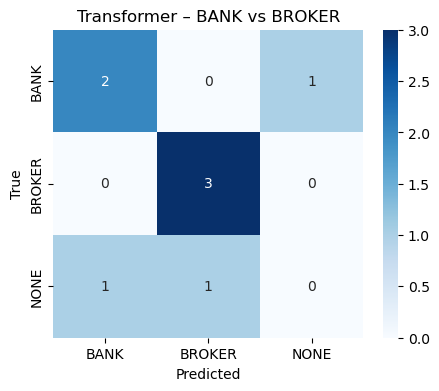

Confusion для LLM:


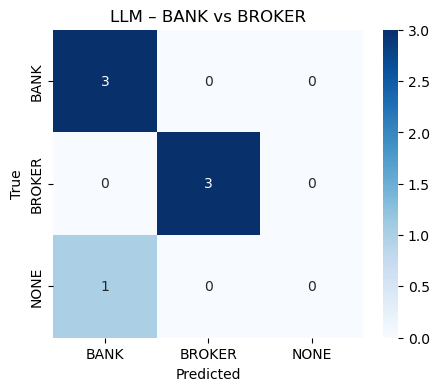


Ошибки трансформера:
  BANK → BROKER: 0
  BROKER → BANK: 0
  BANK → NONE : 1
  BROKER → NONE: 0

Ошибки LLM:
  BANK → BROKER: 0
  BROKER → BANK: 0
  BANK → NONE : 0
  BROKER → NONE: 0


In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def collect_confusion_pairs(examples, model_pred_func, model_name):
    pairs = []
    for ex in examples:
        gold = ex['entities']
        pred = model_pred_func(ex['text'])
        gold_items = [(typ, ent) for typ, lst in gold.items() if typ in ('BANK','BROKER') for ent in lst]
        pred_items = [(typ, ent) for typ, lst in pred.items() if typ in ('BANK','BROKER') for ent in lst]
        gold_set = set((typ, " ".join(ent.lower().split())) for typ, ent in gold_items)
        pred_set = set((typ, " ".join(ent.lower().split())) for typ, ent in pred_items)
        for g_typ, g_ent in gold_set:
            if (g_typ, g_ent) in pred_set:
                pairs.append((g_typ, g_typ))
            else:
                found_other = False
                for p_typ, p_ent in pred_set:
                    if p_ent == g_ent and p_typ != g_typ:
                        pairs.append((g_typ, p_typ))
                        found_other = True
                        break
                if not found_other:
                    pairs.append((g_typ, 'NONE'))
        for p_typ, p_ent in pred_set:
            if not any((g_typ, g_ent) == (p_typ, p_ent) for g_typ, g_ent in gold_set):
                if not any(g_ent == p_ent for _, g_ent in gold_set):
                    pairs.append(('NONE', p_typ))
    return pairs

pairs_tr = collect_confusion_pairs(test_examples_new, entities_from_transformer_new, 'Transformer')
pairs_llm = collect_confusion_pairs(test_examples_new, extract_entities_llm, 'LLM')

def plot_confusion(pairs, title):
    labels = ['BANK', 'BROKER', 'NONE']
    y_true = [p[0] for p in pairs]
    y_pred = [p[1] for p in pairs]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return cm

print("Confusion для Transformer (новая схема):")
cm_tr = plot_confusion(pairs_tr, "Transformer – BANK vs BROKER")
print("Confusion для LLM:")
cm_llm = plot_confusion(pairs_llm, "LLM – BANK vs BROKER")

print("\nОшибки трансформера:")
print(f"  BANK → BROKER: {cm_tr[0,1]}")
print(f"  BROKER → BANK: {cm_tr[1,0]}")
print(f"  BANK → NONE : {cm_tr[0,2]}")
print(f"  BROKER → NONE: {cm_tr[1,2]}")
print("\nОшибки LLM:")
print(f"  BANK → BROKER: {cm_llm[0,1]}")
print(f"  BROKER → BANK: {cm_llm[1,0]}")
print(f"  BANK → NONE : {cm_llm[0,2]}")
print(f"  BROKER → NONE: {cm_llm[1,2]}")

## 7. Бенчмарк нескольких моделей

In [17]:
models_to_test = [
    'cointegrated/rubert-tiny2',
    'DeepPavlov/rubert-base-cased',
    'google-bert/bert-base-multilingual-cased'
]

benchmark_results = []

for model_name in models_to_test:
    print(f"\n=== Тестируем модель: {model_name} ===")
    
    tokenizer_bench = AutoTokenizer.from_pretrained(model_name)
    
    def tokenize_bench(examples):
        tok = tokenizer_bench(examples['tokens'], truncation=True, is_split_into_words=True, max_length=72)
        labels = []
        for i, ner_tags in enumerate(examples['ner_tags']):
            word_ids = tok.word_ids(batch_index=i)
            label_ids = []
            prev_word_id = None
            for word_id in word_ids:
                if word_id is None:
                    label_ids.append(-100)
                elif word_id != prev_word_id:
                    label_ids.append(ner_tags[word_id])
                else:
                    lbl = ner_tags[word_id]
                    if lbl not in (-100, new_label2id['O']):
                        if lbl % 2 == 1:
                            lbl += 1
                    label_ids.append(lbl)
                prev_word_id = word_id
            labels.append(label_ids)
        tok['labels'] = labels
        return tok
    
    tokenized_bench = new_dataset.map(tokenize_bench, batched=True)
    
    model_bench = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(new_label_list),
        id2label=new_id2label,
        label2id=new_label2id,
        ignore_mismatched_sizes=True,
    )
    
    train_args = TrainingArguments(
        output_dir=f'./bench_{model_name.replace("/","_")}',
        num_train_epochs=5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='no',
        logging_strategy='epoch',
        use_cpu=True,
        report_to='none',
        seed=SEED,
        disable_tqdm=True,
    )
    
    trainer_bench = Trainer(
        model=model_bench,
        args=train_args,
        train_dataset=tokenized_bench["train"],
        eval_dataset=tokenized_bench["validation"],
        data_collator=DataCollatorForTokenClassification(tokenizer_bench),
        compute_metrics=compute_metrics_new,
        callbacks=[],
    )
    
    t0_train = time.time()
    trainer_bench.train()
    train_time_bench = time.time() - t0_train
    
    eval_metrics = trainer_bench.evaluate()
    f1_val = eval_metrics.get('eval_f1', 0.0)
    
    ner_pipe_bench = pipeline('ner', model=model_bench, tokenizer=tokenizer_bench, aggregation_strategy='simple', device=-1)
    times = []
    for ex in test_examples_new:
        t0_inf = time.time()
        _ = ner_pipe_bench(ex['text'])
        times.append(time.time() - t0_inf)
    avg_inf_time = np.mean(times)
    
    benchmark_results.append({
        'model': model_name,
        'train_time_sec': train_time_bench,
        'val_f1': f1_val,
        'inference_time_sec': avg_inf_time,
    })
    
    print(f"  Время обучения: {train_time_bench:.2f} с")
    print(f"  F1 на валидации: {f1_val:.4f}")
    print(f"  Среднее время инференса: {avg_inf_time:.4f} с")

df_bench = pd.DataFrame(benchmark_results)
print("\n=== Сравнение моделей по скорости и качеству ===")
print(df_bench.round(4))


=== Тестируем модель: cointegrated/rubert-tiny2 ===


Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expec

...

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params we

{'loss': '1.709', 'grad_norm': '13.51', 'learning_rate': '0.0001644', 'epoch': '1'}
{'eval_loss': '0.6299', 'eval_f1': '0.8148', 'eval_precision': '0.8462', 'eval_recall': '0.7857', 'eval_runtime': '0.1718', 'eval_samples_per_second': '58.21', 'eval_steps_per_second': '17.46', 'epoch': '1'}
{'loss': '0.6173', 'grad_norm': '8.955', 'learning_rate': '0.0001244', 'epoch': '2'}
{'eval_loss': '0.264', 'eval_f1': '0.963', 'eval_precision': '1', 'eval_recall': '0.9286', 'eval_runtime': '0.1769', 'eval_samples_per_second': '56.54', 'eval_steps_per_second': '16.96', 'epoch': '2'}
{'loss': '0.2676', 'grad_norm': '9.64', 'learning_rate': '8.444e-05', 'epoch': '3'}
{'eval_loss': '0.1325', 'eval_f1': '0.8475', 'eval_precision': '0.8065', 'eval_recall': '0.8929', 'eval_runtime': '0.1699', 'eval_samples_per_second': '58.86', 'eval_steps_per_second': '17.66', 'epoch': '3'}
{'loss': '0.1553', 'grad_norm': '22.16', 'learning_rate': '4.444e-05', 'epoch': '4'}
{'eval_loss': '0.06291', 'eval_f1': '0.9474',

## 8. Результаты

In [19]:
df_results.to_csv("ner_llm_comparison_detailed.csv", index=False, encoding="utf-8-sig")
df_agg.to_csv("ner_llm_comparison_summary.csv", index=False, encoding="utf-8-sig")
df_bench.to_csv("model_benchmark.csv", index=False, encoding="utf-8-sig")

print("CSV файлы сохранены:")
print(" - ner_llm_comparison_detailed.csv")
print(" - ner_llm_comparison_summary.csv")
print(" - model_benchmark.csv")

CSV файлы сохранены:
 - ner_llm_comparison_detailed.csv
 - ner_llm_comparison_summary.csv
 - model_benchmark.csv


### 1.
 Сравните F1 по EXCHANGE.
F1 трансформера по классу EXCHANGE = 0,125 из‑за недостатка примеров; LLM не выделяет EXCHANGE, сравнение только для трансформера.

### 2.
Как изменилась точность по BROKER и новому ACCOUNT_TYPE?
F1 по BROKER снизился с 0,5625 до 0,375 после выноса ИИС и «счёта». F1 по ACCOUNT_TYPE = 0,125 (мало примеров).

### 3.
Как изменился F1 по BROKER после введения FIN_PRODUCT?
F1 по BROKER упал с 0,5625 до 0,375.

Какова точность по новому классу FIN_PRODUCT?
F1 по FIN_PRODUCT = 0,125 (модель не смогла обучиться из‑за единичных примеров).

### 4.
Кто чаще путает BANK и BROKER — трансформер или LLM?
Ни одна модель не перепутала BANK с BROKER. Трансформер один раз пропустил BANK (NONE), LLM ошибок не допустила.

### 5.
Сравните модели по качеству и скорости. Есть ли модель с лучшим компромиссом «качество / время» на CPU?
rubert‑tiny2: F1=0,667, инференс 0,0034 с; rubert‑base‑cased: F1=0,897, 0,0328 с; multilingual‑bert: F1=1,0, 0,0339 с. Лучший компромисс — rubert‑base‑cased (почти максимальное качество при умеренном времени).

### 6.
Где LLM выигрывает/проигрывает трансформеру по данным из CSV?
LLM выигрывает в извлечении цельных названий (Альфа‑Банк), проигрывает в полноте по AMOUNT и TICKER.

По каким типам сущностей качество особенно отличается?
Наибольшее различие: AMOUNT (трансформер F1=1,0; LLM=0,833) и TICKER (трансформер 0,5; LLM 0,375).

